In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/SEMS/PySESM.zip
!pip install torchmetrics
!mkdir figs_1
!mkdir figs_2
!mkdir figs_3
!mkdir figs_4

Archive:  /content/drive/MyDrive/SEMS/PySESM.zip
   creating: PySESM/
  inflating: PySESM/__init__.py      
   creating: PySESM/base_functions/
  inflating: PySESM/base_functions/Function.py  
  inflating: PySESM/base_functions/__init__.py  
   creating: PySESM/models/
  inflating: PySESM/models/DictLayer.py  
  inflating: PySESM/models/ISTALayer.py  
  inflating: PySESM/models/__init__.py  
   creating: PySESM/models/SESM/
  inflating: PySESM/models/SESM/SESM.py  
  inflating: PySESM/models/SESM/__init__.py  
   creating: PySESM/test_functions/
  inflating: PySESM/test_functions/MultivariateNormal.py  
  inflating: PySESM/test_functions/__init__.py  
   creating: PySESM/utils/
  inflating: PySESM/utils/__init__.py  
  inflating: PySESM/utils/linalg.py  
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.4/840.4 kB 5.3 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
from torchmetrics import MeanSquaredError, Accuracy, Precision, Recall, F1Score
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
from PySESM.models.SESM.SESM import SESM_Model
from PySESM.base_functions.Function import GaussianFunctions


## Definicion de covarianzas no diagnonales

In [ ]:

# Non-diagonal covariance
def generate_sigma_tensors():
    e0 = torch.tensor([1.0, 1.0], dtype=torch.float32)
    e0 = e0 / e0.norm()

    def generate_sigma(rotation_angle, scaling_factors):
        rotation_matrix = torch.tensor([[np.cos(rotation_angle), -np.sin(rotation_angle)],
                                       [np.sin(rotation_angle), np.cos(rotation_angle)]], dtype=torch.float32)
        e = torch.mm(rotation_matrix, e0.unsqueeze(1))
        E = torch.cat((e0.unsqueeze(1), e), dim=1)
        D = torch.diag(torch.tensor(scaling_factors, dtype=torch.float32))
        return torch.mm(torch.mm(E, D), E.t())

    sigma1 = generate_sigma(np.pi/4, [0.5, 0.4])
    sigma2 = generate_sigma(np.pi/2, [0.05, 0.5])
    sigma3 = generate_sigma(np.pi/8, [0.2, 0.1])

    return sigma1, sigma2, sigma3


In [ ]:
sigma1, sigma2, sigma3 = generate_sigma_tensors()
# Calculate covariance matrix
cov_matrix = torch.stack([sigma1.flatten(), sigma2.flatten(), sigma3.flatten()]).cov()
# Verify covariance
print(cov_matrix)

tensor([[0.0400, 0.0333, 0.0057],
        [0.0333, 0.0833, 0.0024],
        [0.0057, 0.0024, 0.0009]])


## Definicion de varianzas diagonales

In [ ]:
sigma1_d = 0.1 * torch.eye(2)
sigma2_d = 0.2 * torch.eye(2)
sigma3_d = 0.3 *torch.eye(2)

## Funcion para los sub-bloques

In [ ]:
class SubBlock:
    """
    Represents a sub-block in a 2D grid.

    Attributes:
    - vertices (np.ndarray): The vertices of the sub-block.
    - samples_inside (list): List of samples inside the sub-block.
    - output_values (list): List of output values.

    Methods:
    - add_point(point): Add a point to the sub-block.
    """
    def __init__(self, vertices):
        self.vertices = vertices
        self.samples_inside  = []
        self.output_values = []

    def add_point(self, point, y):
        self.samples_inside.append(point)
        self.output_values.append(y)

def get_sub_block_vertices(grid_size, row, col):
    """
    Get the vertices of a sub-block in a 2D grid.

    Args:
    - grid_size (int): The number of segments per dimension.
    - row (int): The row index of the sub-block.
    - col (int): The column index of the sub-block.

    Returns:
    np.ndarray: The vertices of the sub-block.
    """
    delta = 1.0 / grid_size
    x0 = col * delta
    x1 = (col + 1) * delta
    y0 = row * delta
    y1 = (row + 1) * delta
    return np.array([[x0, y0], [x1, y0], [x0, y1], [x1, y1]])


def locate_samples_in_sub_blocks(x_n, y, t, grid_size):
    """
    Locate points in their respective sub-blocks in a 2D grid.

    Args:
    - x_n (np.ndarray): The normalized points between 0 and 1.
    - y (np.narray) : The output values associated with the samples
    - t (np.ndarray): The integer part of the normalized points.
    - grid_size (int): The number of segments per dimension.

    Returns:
    np.ndarray: Array of SubBlock instances representing the sub-blocks.
    """

    sub_blocks = np.empty((grid_size, grid_size), dtype=object)

    for row in range(grid_size):
        for col in range(grid_size):
            sub_blocks[row, col] = SubBlock(get_sub_block_vertices(grid_size, row, col))

    for i in range(x_n.shape[0]):
        point = x_n[i]
        location = t[i]
        #print(location)
        if location[0] > grid_size - 1:
          continue
        if location[1] > grid_size - 1:
          continue

        sub_block = sub_blocks[location[0], location[1]]
        sub_block.add_point(point, y[i])

    return sub_blocks


In [ ]:
#Get Squeeze Factor for Output values
def squeze_factor(Y):
  e_f   = 0.0
  max_y = Y.max()
  if max_y > 1:
    e_f = 1/max_y
  else:
    e_f = 1.0
  return e_f

## Crear Gaussianas

In [ ]:
def create_Myu(size, low, high):
    return torch.rand(size) * (high - low) + low

In [ ]:
def generate_mesh_and_z(sigma1, sigma2, sigma3):
    N_points = 50
    xl = -2
    xr = 2

    x = np.linspace(xl, xr, N_points+1)
    xx, yy = np.meshgrid(x, x)

    X = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float32)

    mu1 = create_Myu(2, -2,  2)
    mu2 = create_Myu(2, -2,  2)
    mu3 = create_Myu(2, -2,  2)

    z1 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu1.numpy(), sigma1.numpy()), dtype=torch.float32)
    z2 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu2.numpy(), sigma2.numpy()), dtype=torch.float32)
    z3 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu3.numpy(), sigma3.numpy()), dtype=torch.float32)

    zz = (z1 + z2 + z3).reshape(xx.shape)

    return xx, yy, zz




## Covarianza de gaussianas del experimento:
  - 3 Diagonales
  - 2 Diagonales, 1 no diagonal
  - 1 diagonal, 2 no diagonales
  - 3 no diagonales

In [ ]:
import csv

def save_results(data, expe):
  # Calcular el promedio y la desviación estándar para time y mse
  times = [item[1] for item in data]
  mse_values = [item[2] for item in data]

  average_time = np.mean(times)
  std_time = np.std(times)
  average_mse = np.mean(mse_values)
  std_mse = np.std(mse_values)

  # Guardar los datos en un archivo CSV
  with open(f"resultados_{expe}.csv", mode="w", newline="") as file:
      writer = csv.writer(file)
      writer.writerow(["iter", "Tiempo (min)", "mse"])
      writer.writerows(data)
      writer.writerow(["Promedio", average_time, average_mse])
      writer.writerow(["Desviación Estándar", std_time, std_mse])


In [ ]:
# 3 diag
xx, yy, zz = generate_mesh_and_z(sigma1_d, sigma2_d, sigma3_d)

# 2 diag, 1 no diag
xx_1, yy_1, zz_1 = generate_mesh_and_z(sigma1_d, sigma2_d, sigma3)

# 1 diag, 2 no diag
xx_2, yy_2, zz_2 = generate_mesh_and_z(sigma1_d, sigma2, sigma3)
# 3 no diag
xx_3, yy_3, zz_3 = generate_mesh_and_z(sigma1, sigma2, sigma3)

In [21]:
fig = go.Figure(data=[go.Surface(z=zz_3.numpy(), x=xx_3, y=yy_3)])
fig.update_layout(scene=dict(aspectmode='data'))
fig.update_layout(scene=dict(camera=dict(eye=dict(x=2, y=2, z=1))))

fig.show()

In [ ]:
from google.colab import files

N_iter        = 1
m_epochs      = 20
dict_epochs   = 60
h_epochs      = 100
T             = 5

# Nomenclatura de experimentos

<Set de hiperparámetros>. <Set de datos (conjunto de gaussianas)>.<Número de repetición del experimento>


## Set de Hiperparámetros
|  Hiperparámetro | Exp 1.x.x     | Exp 2.x.x     | Exp 3.x.x     |
|-----------------|---------------|---------------|---------------|
| n_samples       | 50            | 100           | 500           |
| n_features      | 2             | 2             | 2             |
| l_functions     | 20            | 6             | 10            |
| ista_alpha      | 0.06          | 0.0125        | 0.0125        |
| ista_lambd      | 0.005         | 0.001         | 0.001         |
| dictionary_alpha| 0.06          | 0.0125        | 0.0125        |
| m_epochs        | 25            | 500           | 300           |
| dict_epochs     | 800           | 20            | 60            |
| h_epochs        | 1000          | 50            | 100           |


### Set de datos

|     Set      | Exp 1.x.x     | Exp 2.x.x     | Exp 3.x.x     |
|-----------------|---------------|---------------|---------------|
| Gaussianas 1    | Exp 1.1.x     | Exp 2.1.x     | Exp 3.1.x     |
| Gaussianas 2    | Exp 1.2.x     | Exp 2.2.x     | Exp 3.2.x     |
| Gaussianas 3    | Exp 1.3.x     | Exp 2.3.x     | Exp 3.3.x     |
| Gaussianas 4    | Exp 1.4.x     | Exp 2.4.x     | Exp 3.4.x     |


In [ ]:
T = 4 #number of sub-blks
data = {"x0": xx.ravel(), "x1": yy.ravel()}
df = pd.DataFrame(data)
norm_x = (df-df.min())/((df.max()-df.min())/T)
print(norm_x.head(200))

In [ ]:
t  = norm_x.astype(int)
t.head(200)

In [ ]:
x_n = norm_x - t
x_n.head(20)

In [23]:
def run_experiment(_x, _y, _z, m_epochs, dict_epochs, h_epochs,expe, iter, T, debug=True):
  x_values = _x.ravel()
  y_values = _y.ravel()
  z_values = _z.ravel()

  n_samples = 500 # pueden aumentarse
  n_features = 2
  l_functions =  10 # bajarlas a <10
  total_points = len(x_values)

  min_separation = 1 # se puede reducir

  selected_indexes = []
  #Generate a uniform sampling
  while len(selected_indexes) < n_samples:

      random_index = np.random.randint(total_points)

      if all(abs(random_index - existing_index) >= min_separation for existing_index in selected_indexes):
          selected_indexes.append(random_index)

  sampled_indices = selected_indexes

  sampled_x = torch.tensor(x_values[sampled_indices], dtype=torch.float32)
  sampled_y = torch.tensor(y_values[sampled_indices], dtype=torch.float32)

  y = z_values[sampled_indices].clone().detach().to(dtype=torch.float32)
  X = torch.stack((sampled_x, sampled_y), dim=1)
  print(f"Input tensor shape ORIGINAL: {X.shape}")
  print(f"Target tensor shape ORIGINAL: {y.shape}")
  # Imprimir los primeros 5 valores de `y`
  #print("Los primeros 5 valores de y son:")
  #print(y[:5])  # Usa la indexación de tensores para obtener los primeros 5 valores

  # Si deseas imprimir los primeros 5 valores de `X` también, puedes hacer lo siguiente
  #print("\nLos primeros 5 valores de X son:")
  #print(X[:5])

  #Escaled and normalized samples
  x_norm = ( X - X.min() ) / ( ( X.max() - X.min() ) / T )
  #Scaled Y
  ampl=squeze_factor(y)
  y = y*ampl
  # The integer part of the normalized samples
  t  = x_norm.numpy().astype(int)
  # Normalized samples from 0 to 1
  x_n = x_norm - t
  # All the sub-blocks (2^T)
  sub_blocks = locate_samples_in_sub_blocks(x_n.numpy(), y.numpy(), t, T)
  # List for all the sub-blocks
  list_sub_blocks = []
  for row in sub_blocks:
    for block in row:
      if(len(block.output_values) != 0):
        list_sub_blocks.append(block)

  print(len(list_sub_blocks))
  gaussian_function = GaussianFunctions(n_features= n_features, n_functions = l_functions)
  # model = SESM_Model(
  #  n_samples=n_samples,
  #  n_features=n_features,
  #  n_functions=l_functions,
  #  psi=gaussian_function.gaussian,
  #  initialization="Lecun"
  #  )

  model_epochs = m_epochs
  ista_epochs = h_epochs
  dictionary_epochs = dict_epochs

  # reajustar estos parametros
  ista_alpha = 0.0125
  ista_lambd = 0.001
  dictionary_alpha = 0.0125
  for i in range(5):
    for block in list_sub_blocks:
      y = torch.tensor(block.output_values, dtype=torch.float32)
      X = torch.tensor(block.samples_inside, dtype=torch.float32)
      shape_value = int(y.shape[0])
      model = SESM_Model(
        n_samples= shape_value,
        n_features=n_features,
        n_functions=l_functions,
        psi=gaussian_function.gaussian,
        initialization="Lecun"
      )
      print(f"Input tensor shape BLOQUES: {X.shape}")
      print(f"Target tensor shape BLOQUES: {y.shape}")
      #print(f'Block output values tensor: {y} \n')
      #print(f'Block samples inside tensor: {X} \n')
      model.fit(X=X,y=y,model_epochs=model_epochs,ista_epochs=ista_epochs,ista_alpha=ista_alpha,ista_lambd=ista_lambd,dictionary_epochs=dictionary_epochs,dictionary_alpha=dictionary_alpha)

  #model.fit(X=X,y=y,model_epochs=model_epochs,ista_epochs=ista_epochs,ista_alpha=ista_alpha,ista_lambd=ista_lambd,dictionary_epochs=dictionary_epochs,dictionary_alpha=dictionary_alpha)

  x_tensor = torch.tensor(x_values)
  y_tensor = torch.tensor(y_values)

  XY = torch.cat((x_tensor.unsqueeze(1), y_tensor.unsqueeze(1)), dim=1)
  # Calcular el rango original y el mínimo original para XY
  XY_max = XY.max(dim=0, keepdim=True).values
  XY_min = XY.min(dim=0, keepdim=True).values

  # Calcular el rango original
  original_range = (XY_max - XY_min) / T

  # Desnormalizar XY
  XY_original = XY * original_range + XY_min

  Z = model.predict(XY_original)
  #Delete amplification
  Z /=ampl

  time = model.time/60

  #Init MSE metric
  mse = MeanSquaredError()
  # Compute MSE
  mse(Z.clone().detach(), z_values)
  mse_value = mse.compute()

  print(f"Losses lenght: {len(model.dictionary_layer.losses)}")

  if debug:
    fig = plt.figure(figsize=(6, 6))

    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(x_values, y_values, z_values,c=z_values)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('Original Function')


    ax2 = fig.add_subplot(222, projection='3d')
    ax2.scatter(x_values, y_values, Z.clone().detach(), c=Z.clone().detach())
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title('Surrogate Model')
    ax2.set_zlim(0)


    #Show the plot
    fname = f"figs_{expe}/{iter}.png"
    plt.savefig(fname)
    #plt.show()
    plt.clf()

    plt.plot(model.losses)
    plt.ylabel('Loss')
    plt.xlabel('Iteration')
    fname = f"figs_{expe}/{iter}-loss.png"
    plt.savefig(fname)
    print(f"Current h {model.ista_layer.h}")
  return time, mse_value

Input tensor shape ORIGINAL: torch.Size([500, 2])
Target tensor shape ORIGINAL: torch.Size([500])
16
Input tensor shape BLOQUES: torch.Size([21, 2])
Target tensor shape BLOQUES: torch.Size([21])
Epoch 1 Loss: 1.6557520627975464

Epoch 2 Loss: 0.0378883071243763

Epoch 3 Loss: 0.02743149921298027

Epoch 4 Loss: 0.02115998975932598

Epoch 5 Loss: 0.016669226810336113

Epoch 6 Loss: 0.013383952900767326

Epoch 7 Loss: 0.010923420079052448

Epoch 8 Loss: 0.009044887498021126

Epoch 9 Loss: 0.007619685959070921

Epoch 10 Loss: 0.006510808132588863

Epoch 11 Loss: 0.005625763908028603

Epoch 12 Loss: 0.004912047181278467

Epoch 13 Loss: 0.004331218544393778

Epoch 14 Loss: 0.003854578360915184

Epoch 15 Loss: 0.003460376989096403

Epoch 16 Loss: 0.0031319335103034973

Epoch 17 Loss: 0.0028563174419105053

Epoch 18 Loss: 0.0026234204415231943

Epoch 19 Loss: 0.0024252659641206264

Epoch 20 Loss: 0.002255520783364773

Input tensor shape BLOQUES: torch.Size([29, 2])
Target tensor shape BLOQUES:

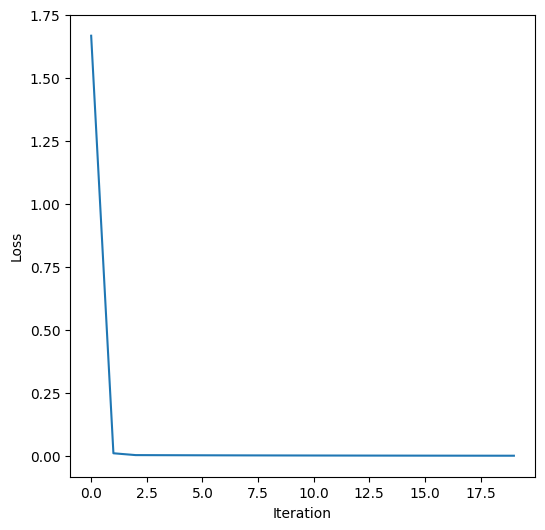

In [24]:
data = []
for i in range(N_iter):
  time, mse = run_experiment(xx,yy,zz,m_epochs=m_epochs,dict_epochs=dict_epochs,h_epochs=h_epochs,T=T, expe=1, iter=i)
  data.append((i, time, mse.item()))

save_results(data=data, expe=1)

In [ ]:
files.download('resultados_1.csv')
!zip -r figs_1.zip figs_1/
files.download('figs_1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_1/ (stored 0%)
  adding: figs_1/0.png (deflated 6%)
  adding: figs_1/0-loss.png (deflated 15%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data_1 = []

for i in range(N_iter):
  time, mse = run_experiment(xx_1,yy_1,zz_1,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=2, iter=i)
  data_1.append((i, time, mse.item()))

save_results(data=data_1, expe=2)

In [ ]:
files.download('resultados_2.csv')
!zip -r figs_2.zip figs_2/
files.download('figs_2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_2/ (stored 0%)
  adding: figs_2/0.png (deflated 6%)
  adding: figs_2/0-loss.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training model:   5%|▌         | 1/20 [00:00<00:10,  1.75it/s]

Epoch 1 Loss: 3.2243423461914062



Training model:  10%|█         | 2/20 [00:01<00:11,  1.56it/s]

Epoch 2 Loss: 0.4867955446243286



Training model:  15%|█▌        | 3/20 [00:01<00:09,  1.70it/s]

...

Training model:  95%|█████████▌| 19/20 [00:07<00:00,  3.84it/s]

Epoch 19 Loss: 0.11485038697719574



Training model: 100%|██████████| 20/20 [00:07<00:00,  2.55it/s]

Epoch 20 Loss: 0.11446542292833328

Losses lenght: 1200


Current h Parameter containing:
tensor([ 0.1252,  0.2793,  0.2460,  0.2433, -0.0739,  0.4347,  0.1491, -0.6073,
         0.2835,  0.2769], requires_grad=True)


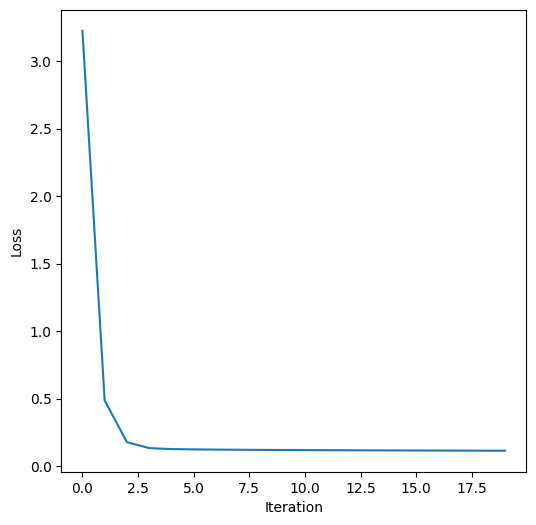

In [ ]:
data_2 = []
for i in range(N_iter):
  time, mse = run_experiment(xx_2,yy_2,zz_2,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=3, iter=i)
  data_2.append((i, time, mse.item()))

save_results(data=data_2, expe=3)

In [ ]:
files.download('resultados_3.csv')
!zip -r figs_3.zip figs_3/
files.download('figs_3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_3/ (stored 0%)
  adding: figs_3/0.png (deflated 5%)
  adding: figs_3/0-loss.png (deflated 16%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training model:   5%|▌         | 1/20 [00:00<00:04,  4.09it/s]

Epoch 1 Loss: 2.327662944793701



Training model:  10%|█         | 2/20 [00:00<00:05,  3.15it/s]

Epoch 2 Loss: 0.5297451615333557



Training model:  15%|█▌        | 3/20 [00:00<00:05,  2.99it/s]

...

Training model:  95%|█████████▌| 19/20 [00:05<00:00,  3.97it/s]

Epoch 19 Loss: 0.05738159641623497



Training model: 100%|██████████| 20/20 [00:05<00:00,  3.41it/s]

Epoch 20 Loss: 0.056840911507606506

Losses lenght: 1200


Current h Parameter containing:
tensor([-0.0272,  0.0166,  0.2171, -0.0554, -0.1659,  0.0907, -0.0768,  0.9170,
         0.4445,  0.0523], requires_grad=True)


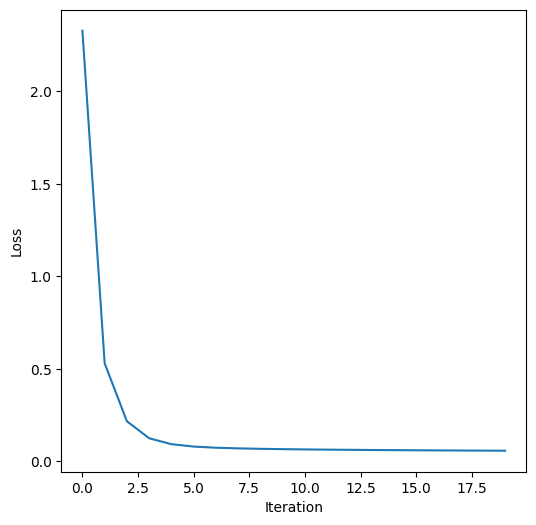

In [ ]:
data_3 = []
for i in range(N_iter):
  time, mse = run_experiment(xx_3,yy_3,zz_3,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=4, iter=i)
  data_3.append((i, time, mse.item()))

save_results(data=data_3, expe=4)

In [ ]:

files.download('resultados_4.csv')
!zip -r figs_4.zip figs_4/
files.download('figs_4.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_4/ (stored 0%)
  adding: figs_4/0.png (deflated 7%)
  adding: figs_4/0-loss.png (deflated 15%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>